In [5]:
from sklearn.datasets import make_blobs

# Generate a synthetic 2D dataset
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)

print("Generated features (X) shape:", X.shape)
print("Generated true labels (y_true) shape:", y_true.shape)
print("First 5 rows of X:\n", X[:5])
print("First 5 rows of y_true:\n", y_true[:5])

Generated features (X) shape: (300, 2)
Generated true labels (y_true) shape: (300,)
First 5 rows of X:
 [[ -9.1139443    6.81361629]
 [ -9.35457578   7.09278959]
 [ -2.01567068   8.28177994]
 [ -7.01023591  -6.22084348]
 [-10.06120248   6.71867113]]
First 5 rows of y_true:
 [3 3 0 2 3]


In [6]:
from sklearn.cluster import AgglomerativeClustering

# Instantiate AgglomerativeClustering with n_clusters=4
agg_cluster = AgglomerativeClustering(n_clusters=4)

# Fit the model to the data and get the cluster labels
agg_labels = agg_cluster.fit_predict(X)

print("Agglomerative Clustering labels shape:", agg_labels.shape)
print("First 10 Agglomerative Clustering labels:", agg_labels[:10])

Agglomerative Clustering labels shape: (300,)
First 10 Agglomerative Clustering labels: [0 0 3 1 0 1 2 1 3 2]


In [7]:
from sklearn.cluster import DBSCAN

# Instantiate DBSCAN with appropriate parameters
dbscan = DBSCAN(eps=0.6, min_samples=5)

# Fit the model to the data and get the cluster labels
dbscan_labels = dbscan.fit_predict(X)

print("DBSCAN labels shape:", dbscan_labels.shape)
print("First 10 DBSCAN labels:", dbscan_labels[:10])

DBSCAN labels shape: (300,)
First 10 DBSCAN labels: [0 0 1 2 0 2 3 2 1 3]


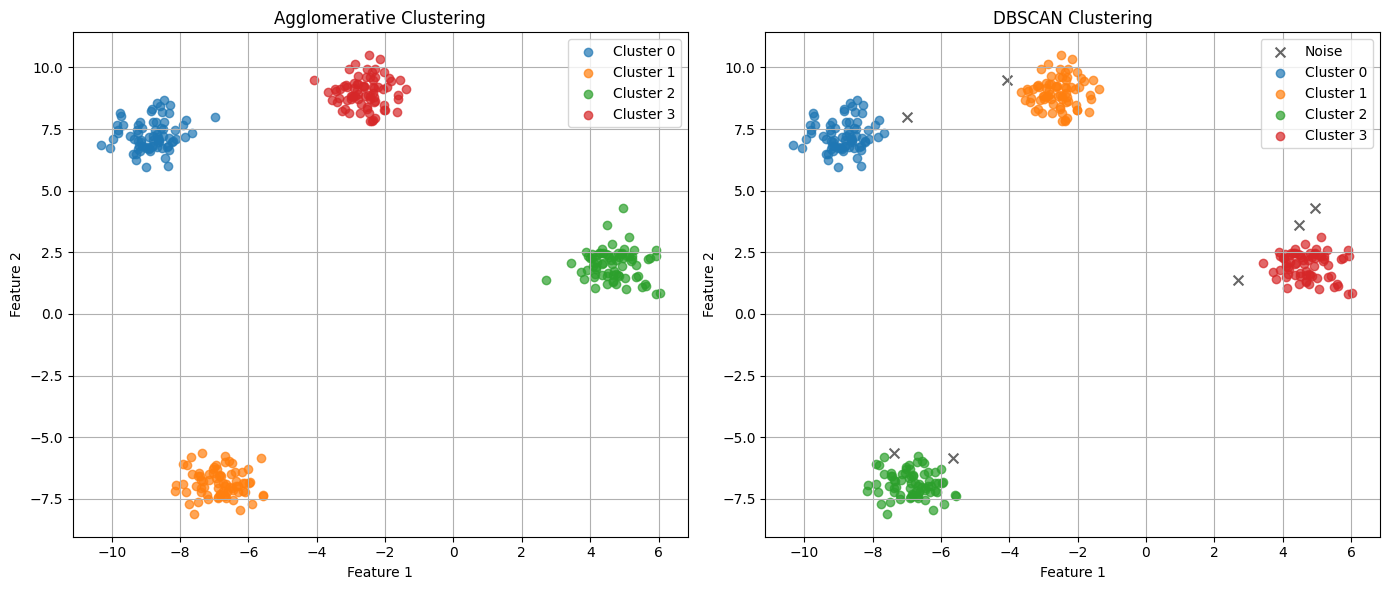

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots
plt.figure(figsize=(14, 6))

# Plot for Agglomerative Clustering
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
unique_agg_labels = np.unique(agg_labels)
for label in unique_agg_labels:
    # Select data points for the current cluster
    cluster_points = X[agg_labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', alpha=0.7)
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)

# Plot for DBSCAN Clustering
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
unique_dbscan_labels = np.unique(dbscan_labels)
for label in unique_dbscan_labels:
    if label == -1: # Noise points
        cluster_points = X[dbscan_labels == label]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c='black', marker='x', s=50, label='Noise', alpha=0.6)
    else:
        cluster_points = X[dbscan_labels == label]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', alpha=0.7)
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

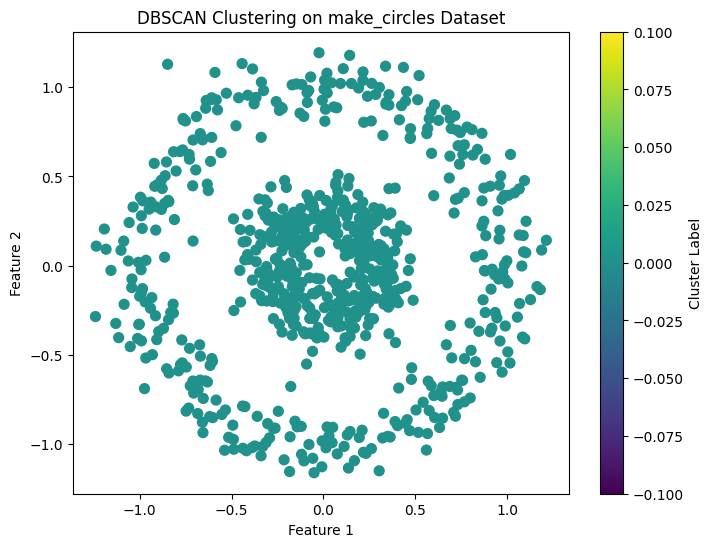

In [9]:
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Generate the make_circles dataset
X, y = make_circles(n_samples=750, factor=0.3, noise=0.1)

# Apply DBSCAN algorithm
dbscan = DBSCAN(eps=0.3, min_samples=10)
clusters = dbscan.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('DBSCAN Clustering on make_circles Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
plt.show()